In [13]:
import Simulated_annealing
import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import random
from heapdict import heapdict

class Image_Denoising(Simulated_annealing.State):
    
    def __init__(self, image : np.ndarray, smoothing_bias : float, change_magnitude = 1):
        self.image = image.copy()
        if self.image.dtype == np.float32 or self.image.dtype == np.float64:
            self.image = (self.image * 255).astype(np.int16)
        self.state = self.image.copy()
        self.y_len, self.x_len, self.channels = image.shape
        self.smoothing_bias = smoothing_bias
        self.original_bias = 1 - smoothing_bias
        self.change_magnitude = change_magnitude
    
    def get_neighbour(self):
        i = random.randrange(0, self.y_len)
        j = random.randrange(0, self.x_len)

        v = np.zeros(shape = self.channels)
        
        for a in range(self.channels):
            v[a] = random.randrange(int(max(self.state[i, j, a] - self.change_magnitude, 0)), int(min(self.state[i, j, a] + self.change_magnitude, 256)))

        return ((i, j), v)
    
    def cost(self, state=None):
        if state is None:
            state = self.state
        
        # 1. Data Fidelity Term
        diff_matrix = state - self.image
        data_energy = np.sum(diff_matrix ** 2)

        # 2. Smoothness Term
        h_diff = state[:, :-1, :] - state[:, 1:, :]
        v_diff = state[:-1, :, :] - state[1:, :, :]
        
        smoothness_energy = np.sum(h_diff ** 2) + np.sum(v_diff ** 2)
        total_cost = (self.original_bias * data_energy) + (self.smoothing_bias * smoothness_energy)
        
        return total_cost
    
    def cost_change(self, move):
        i, j = move[0]
        change = np.array(move[1])

        curr_val = self.state[i, j]
        new_val = change

        old_cost = np.sum((curr_val - self.image[i, j]) ** 2)

        smoothing_cost = 0
        n_neighbours = 0

        if (i + 1 < self.y_len):
            smoothing_cost += np.sum((curr_val - self.state[i+1, j]) ** 2)
            n_neighbours += 1
        if (i - 1 >= 0):
            smoothing_cost += np.sum((curr_val - self.state[i-1, j]) ** 2)
            n_neighbours += 1
        if (j + 1 < self.x_len):
            smoothing_cost += np.sum((curr_val - self.state[i, j+1]) ** 2)
            n_neighbours += 1
        if (j - 1 >= 0):
            smoothing_cost += np.sum((curr_val - self.state[i, j-1]) ** 2)
            n_neighbours += 1
        
        smoothing_cost /= n_neighbours

        old_cost = self.original_bias * old_cost + self.smoothing_bias * smoothing_cost


        new_cost = np.sum((new_val - self.image[i, j]) ** 2)

        smoothing_cost = 0
        n_neighbours = 0

        if (i + 1 < self.y_len):
            smoothing_cost += np.sum((new_val - self.state[i+1, j]) ** 2)
            n_neighbours += 1
        if (i - 1 >= 0):
            smoothing_cost += np.sum((new_val - self.state[i-1, j]) ** 2)
            n_neighbours += 1
        if (j + 1 < self.x_len):
            smoothing_cost += np.sum((new_val - self.state[i, j+1]) ** 2)
            n_neighbours += 1
        if (j - 1 >= 0):
            smoothing_cost += np.sum((new_val - self.state[i, j-1]) ** 2)
            n_neighbours += 1
        
        smoothing_cost /= n_neighbours

        new_cost = self.original_bias * new_cost + self.smoothing_bias * smoothing_cost

        return (new_cost - old_cost)
    
    def update(self, move):
        i, j = move[0]
        change = np.array(move[1])

        self.state[i, j] = change
        return
    
    def get_all_neighbours(self):
        queue = heapdict()

        for i in range(self.x_len):
            for j in range(self.y_len):
                v1 = np.minimum(self.state[i, j] + 1, 256)
                v2 = np.maximum(self.state[i, j] - 1, 0)

                queue[((i, j), tuple(v1))] = self.cost_change(((i, j), v1))
                queue[((i, j), tuple(v2))] = self.cost_change(((i, j), v2))
        
        return queue
    
    def get_affected_moves(self, move, queue):
        (i, j), new_val_tuple = move
        
        original_val = self.state[i, j].copy()
        
        # Check for the stale +1 move
        v1_old = np.minimum(original_val + 1, 255)
        if not np.array_equal(v1_old, original_val):
            k1 = ((i, j), tuple(v1_old))
            if k1 in queue:
                del queue[k1]
        
        # Check for the stale -1 move
        v2_old = np.maximum(original_val - 1, 0)
        if not np.array_equal(v2_old, original_val):
            k2 = ((i, j), tuple(v2_old))
            if k2 in queue:
                del queue[k2]

        # Temporarily Apply the move
        self.state[i, j] = np.array(new_val_tuple)

        # Identify coordinates to update
        coords_to_update = [(i, j)]
        if i > 0: coords_to_update.append((i - 1, j))
        if i < self.y_len - 1: coords_to_update.append((i + 1, j))
        if j > 0: coords_to_update.append((i, j - 1))
        if j < self.x_len - 1: coords_to_update.append((i, j + 1))
        
        # Re-calculate moves for these pixels
        for r, c in coords_to_update:
            curr_val = self.state[r, c]
        
            v1 = np.minimum(curr_val + 1, 255)
            if not np.array_equal(v1, curr_val):
                queue[((r, c), tuple(v1))] = self.cost_change(((r, c), v1))
            
            v2 = np.maximum(curr_val - 1, 0)
            if not np.array_equal(v2, curr_val):
                queue[((r, c), tuple(v2))] = self.cost_change(((r, c), v2))

        # Revert the state
        self.state[i, j] = original_val
                
        return queue


Run 1 / 10
Temperature : 100.0000  Best cost : 161164922.49999186

Run 2 / 10
Temperature : 50.0000  Best cost : 161164922.49999186

Run 3 / 10
Temperature : 25.0000  Best cost : 161164866.24999186

Run 4 / 10
Temperature : 12.5000  Best cost : 161164844.59999186

Run 5 / 10
Temperature : 6.2500  Best cost : 161148305.11665866

Run 6 / 10
Temperature : 3.1250  Best cost : 161143642.04999197

Run 7 / 10
Temperature : 1.5625  Best cost : 161113220.1499916

Run 8 / 10
Temperature : 0.7812  Best cost : 161109949.89999157

Run 9 / 10
Temperature : 0.3906  Best cost : 161089288.68332514

Run 10 / 10
Temperature : 0.1953  Best cost : 161083858.66665852

Final local search
Best cost : 40285816.5333333

Completed Annealing


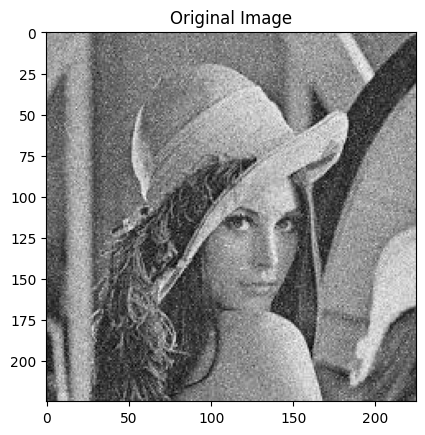

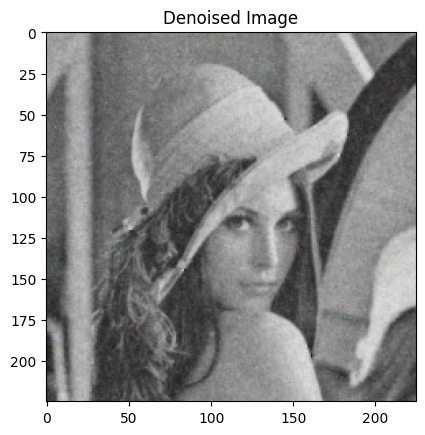

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-80..82].


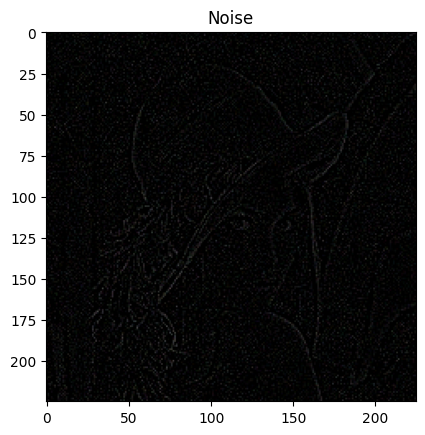

In [18]:
image_path = "Files/Noisy_image_bw_3.png"
image = (mpimg.imread(image_path) * 255).astype(np.int16)

Image_state = Image_Denoising(image, smoothing_bias = 0.7, change_magnitude = 20)
Solver = Simulated_annealing.Annealer(Image_state, initial_temp= 100, temperature_schedule = 'exponential', scheduling_constant = 0.001)

Solver.anneal(unchanged_threshold = 1000, reset_temp = 0.5, n_runs=10, local_search = True)
print("Completed Annealing")

denoised_image = Image_state.state

plt.imshow(image)
plt.title("Original Image")
plt.show()

plt.imshow(denoised_image)
plt.title("Denoised Image")
plt.show()

plt.imshow(image - denoised_image)
plt.title("Noise")
plt.show()

np.float64(0.0)